In [65]:
import numpy as np

import jax
import jax.numpy as jnp

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import pandas as pd

import optax
from tqdm import tqdm

In [2]:
HIDDEN_STATE_SHAPE = 8

In [3]:
def RNN(params, xseq):
    Wx, Wh,b, Wout, bout = params
    h=np.zeros(HIDDEN_STATE_SHAPE)
    for x in xseq:
        h = jax.nn.tanh(x*Wx + Wh @ h + b)
    out = jnp.dot(h,Wout) + bout
    return out.astype(jnp.float32)

RNNvmap = jax.vmap(RNN, in_axes=(None,0), out_axes=0)

In [4]:
params = [np.random.randn(HIDDEN_STATE_SHAPE), np.random.randn(HIDDEN_STATE_SHAPE,HIDDEN_STATE_SHAPE), np.random.randn(HIDDEN_STATE_SHAPE),
         np.random.randn(8), np.random.randn()]

In [12]:
data = pd.read_csv("temperature.csv")
data.Year = pd.to_datetime(data.Year)

#Train
X = data.Anomaly[data.Year < pd.to_datetime("2000") ].to_numpy()
XYears = data.Year[data.Year < pd.to_datetime("2000") ].to_numpy()
#Test
TX = data.Anomaly[data.Year >= pd.to_datetime("2000") ].to_numpy()
TXYears = data.Year[data.Year >= pd.to_datetime("2000") ].to_numpy()

# MinMax Normalize\
M,m = X.max(), X.min()
X = X - m
X = X / (M - m)

In [13]:
# 24 Month long sequences
SEQLEN = 24
Xtrain = np.array([X[i:i+SEQLEN] for i in range(X.shape[0] - SEQLEN - 1)])
Ytrain = np.array([X[i+SEQLEN] for i in range(X.shape[0] - SEQLEN - 1)])


#Xtest
Xtest = np.array([TX[i:i+SEQLEN] for i in range(TX.shape[0] - SEQLEN - 1)])


np.array([RNN(params, x) for x in Xtrain]), RNNvmap(params, Xtrain)

(array([0.44617087, 0.42860264, 0.42365518, ..., 0.6672853 , 0.67831206,
        0.67496824], shape=(1775,), dtype=float32),
 Array([0.44628564, 0.42868888, 0.423753  , ..., 0.66743296, 0.6784136 ,
        0.6750514 ], dtype=float32))

In [14]:
for i in range(len(Ytrain)-1):
    assert Ytrain[i] == Xtrain[i+1][-1]

In [15]:
jax.jit
def lossfn(params, Xt, yt):
    # yhat = [RNN(params, x).astype(float) for x in Xt]
    yhat = RNNvmap(params, Xtrain)
    err = jnp.array(yhat) - jnp.array(yt)
    return jnp.mean(err**2)

dlossfn = jax.jit(jax.value_and_grad(lossfn))

In [16]:
params = [np.random.randn(HIDDEN_STATE_SHAPE), np.random.randn(HIDDEN_STATE_SHAPE,HIDDEN_STATE_SHAPE), np.random.randn(HIDDEN_STATE_SHAPE),
         np.random.randn(8), np.random.randn()]
params = [p*0.1 for p in params] # scale closer to zero

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),      # clip to prevent explosions
    optax.amsgrad(learning_rate=1e-3)
)

# optimizer = optax.amsgrad(learning_rate=1e-3)

state = optimizer.init(params)

EPOCHS = 1500
pbar =  tqdm(range(EPOCHS), colour="blue", ncols=100, position=0)

for i in pbar:
    loss, grads = dlossfn(params, Xtrain, Ytrain)
    updates, state = optimizer.update(grads, state, params)
    params = optax.apply_updates(params, updates)
    pbar.set_postfix_str(f"loss:{loss:.5f}")
    #print(updates[0])
    #print(params[0])
    

100%|████████████████████████████████████████████| 1500/1500 [00:06<00:00, 221.40it/s, loss:0.00463]


Text(0.5, 1.0, 'Train Partition')

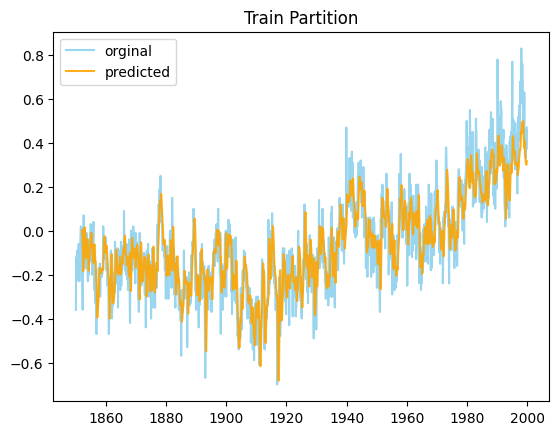

In [24]:
sns.lineplot(x=XYears, y=X*(M-m)+m, alpha=0.85, color="skyblue", label="orginal")
sns.lineplot(x=XYears[SEQLEN+1:],y=RNNvmap(params, Xtrain)*(M-m)+m, alpha=0.9,color="orange", label="predicted")
plt.title("Train Partition")

(np.float64(10957.0), np.float64(14610.0))

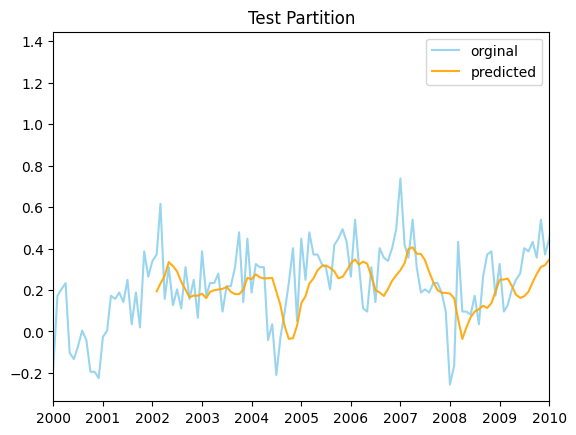

In [29]:
sns.lineplot(x=TXYears, y=TX*(M-m)+m, alpha=0.85, color="skyblue", label="orginal")
sns.lineplot(x=TXYears[SEQLEN+1:],y=RNNvmap(params, Xtest)*(M-m)+m, alpha=0.9,color="orange", label="predicted")
plt.title("Test Partition")
plt.xlim(pd.to_datetime("2000"), pd.to_datetime("2010"))

Text(0.5, 1.0, 'Predicting 36 months into the future')

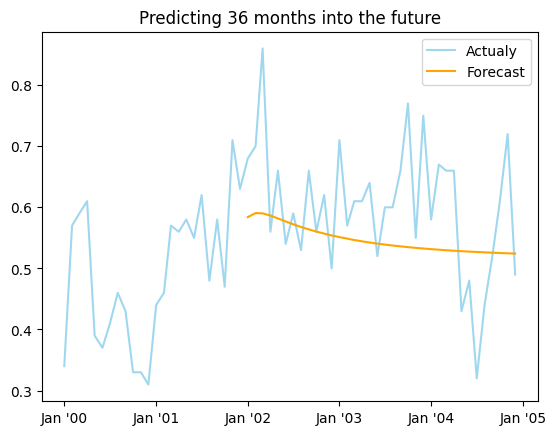

In [73]:
# Predicting three years into the future
PREDLEN = 36
_X = Xtest[0].tolist()
for i in range(PREDLEN):
    _X += [float(RNN(params, _X[-SEQLEN:]))]
    
sns.lineplot(x=TXYears[:SEQLEN+PREDLEN], y=TX[:SEQLEN+PREDLEN], alpha=0.8, color="skyblue", label="Actualy")
sns.lineplot(x=TXYears[SEQLEN:SEQLEN+PREDLEN],y=_X[SEQLEN:SEQLEN+PREDLEN], color="orange", label="Forecast")
ax = plt.gca() 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

plt.title("Predicting 36 months into the future")